In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import random

In [21]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder/training_index.csv")
IMG_DIR = Path("../images/LTEM_images_ku_by_blocks_mz_binary")
IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma"

IMG_EXT = ".png"   # image extension
IMG_PREFIX = "mz_binary_"   # image name pattern: mz_binary_<idx>.png

BATCH_SIZE = 10
LR = 5e-5
EPOCHS = 50
VAL_RATIO = 0.2
RANDOM_SEED = 42
MODEL_TYPE = "normal"   # Options: "resnet", "physics", "normal", "physics_normal" 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:
# Helper to calculate physics metrics on the CPU
def calculate_physics_metrics(img_tensor):
    """
    img_tensor: [1, H, W] or [3, H, W] normalized tensor
    Returns: [edge_density, mean_magnetization]
    """
    # 1. Mean Magnetization (Overall bias)
    mean_mag = torch.mean(img_tensor)
    
    # 2. Edge Density (Total Variation / Gradient Magnitude)
    # We compute gradients in X and Y
    # img is [C, H, W]
    if img_tensor.shape[0] == 3:
        x = img_tensor[0:1, :, :] # take one channel
    else:
        x = img_tensor
        
    dy = torch.abs(x[:, 1:, :] - x[:, :-1, :])
    dx = torch.abs(x[:, :, 1:] - x[:, :, :-1])
    
    edge_density = (torch.mean(dy) + torch.mean(dx)) * 100 # scale up for numerical stability
    
    return torch.tensor([edge_density, mean_mag], dtype=torch.float32)

# -----------------------------
# 2) Dataset
# -----------------------------
#class BinaryMzDataset(Dataset):
#    def __init__(self, csv_path, img_dir, index_col, transform, target_mean=None, target_std=None, fit_stats=False):
#        self.df = pd.read_csv(csv_path)
#        self.img_dir = img_dir
#        self.transform = transform
#        self.index_col = index_col
#
#        # build record list
#        self.records = []
#        for _, row in self.df.iterrows():
#            idx = int(row[index_col])
#            img_name = f"{IMG_PREFIX}{idx}{IMG_EXT}"
#            img_path = img_dir / img_name
#
#            if img_path.is_file():
#                self.records.append({
#                    "img_path": img_path,
#                    "D": float(row[COL_D]),
#                    "sigma": float(row[COL_SIGMA]),
#                })
#
#        if len(self.records) == 0:
#            raise RuntimeError("No image–CSV matches. Check IMG_INDEX_COL and filenames.")
#
#        self.targets = np.array([[r["D"], r["sigma"]] for r in self.records], dtype=np.float32)
#
#        if fit_stats:
#            self.target_mean = self.targets.mean(axis=0, keepdims=True)
#            self.target_std = self.targets.std(axis=0, keepdims=True)
#            self.target_std[self.target_std == 0] = 1.0
#        else:
#            self.target_mean = target_mean
#            self.target_std = target_std
#
#    def __len__(self):
#        return len(self.records)
#
#    def __getitem__(self, idx):
#        r = self.records[idx]
#
#        img = Image.open(r["img_path"]).convert("L")
#        img = self.transform(img)   # tensor [1,512,512]
#        # img shape: [1, H, W]  -> make it 3-channel for ResNet
#        if img.shape[0] == 1:
#            img = img.repeat(3, 1, 1)
#
#        target = np.array([r["D"], r["sigma"]], dtype=np.float32)
#        target = (target - self.target_mean[0]) / self.target_std[0]  # normalize
#        target = torch.tensor(target, dtype=torch.float32)
#
#        return img, target
class BinaryMzDataset(Dataset):
    def __init__(self, csv_path, img_dir, index_col, transform, target_mean=None, target_std=None, fit_stats=False):
        # ... (Same init code as before) ...
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.records = []
        for _, row in self.df.iterrows():
            idx = int(row[index_col])
            img_name = f"{IMG_PREFIX}{idx}{IMG_EXT}"
            img_path = img_dir / img_name
            if img_path.is_file():
                self.records.append({
                    "img_path": img_path,
                    "D": float(row[COL_D]),
                    "sigma": float(row[COL_SIGMA]),
                })
        self.targets = np.array([[r["D"], r["sigma"]] for r in self.records], dtype=np.float32)

        if fit_stats:
            self.target_mean = self.targets.mean(axis=0, keepdims=True)
            self.target_std = self.targets.std(axis=0, keepdims=True)
            self.target_std[self.target_std == 0] = 1.0
        else:
            self.target_mean = target_mean
            self.target_std = target_std

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = Image.open(r["img_path"]).convert("L")
        
        # Apply transform
        img_t = self.transform(img)
        
        # --- NEW: Extract Physics Features ---
        phys_feats = calculate_physics_metrics(img_t) # Shape [2]

        if img_t.shape[0] == 1:
            img_t = img_t.repeat(3, 1, 1)

        target = np.array([r["D"], r["sigma"]], dtype=np.float32)
        target = (target - self.target_mean[0]) / self.target_std[0]
        target = torch.tensor(target, dtype=torch.float32)

        # Return 3 items: Image, Physics, Target
        return img_t, phys_feats, target


In [23]:
# Custom transform for 90-degree rotations (no blur)
class RandomRot90:
    def __call__(self, x):
        k = random.randint(0, 3) # 0, 90, 180, 270 degrees
        return TF.rotate(x, k * 90)

train_tf = T.Compose([
    # If your GPU allows, try to REMOVE Resize and train on 512x512
    # If you must resize, use NEAREST neighbor to preserve sharp domain walls
    #T.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST), 
    
    # Physics augmentations
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    RandomRot90(),  # New custom rotation
    
    T.ToTensor(),
])

val_tf = T.Compose([
    #T.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor(),
])

In [24]:
# First pass dataset to compute mean/std
stats_dataset = BinaryMzDataset(CSV_PATH, IMG_DIR, IMG_INDEX_COL, val_tf, fit_stats=True)

t_mean = stats_dataset.target_mean
t_std = stats_dataset.target_std
print("Target mean:", t_mean)
print("Target std :", t_std)

# Build full dataset using mean/std
full_dataset = BinaryMzDataset(
    CSV_PATH, IMG_DIR, IMG_INDEX_COL,
    transform=None,  # to be overridden
    target_mean=t_mean, target_std=t_std,
    fit_stats=False
)


Target mean: [[0.00071308 0.07582161]]
Target std : [[0.00043231 0.04386081]]


In [25]:
# split indices
val_size = int(len(full_dataset) * VAL_RATIO)
train_size = len(full_dataset) - val_size

torch.manual_seed(RANDOM_SEED)
train_idx, val_idx = random_split(range(len(full_dataset)), [train_size, val_size])


In [26]:
# -----------------------------
# 3b) Unified Dataset Subset Helper
# -----------------------------
# We always calculate physics metrics. 
# If the model doesn't need them, the training loop will just ignore them.
# This prevents "ValueError: not enough values to unpack".

def subset_dataset(indices, transform):
    # We grab the records from the main stats_dataset
    subset_records = [stats_dataset.records[i] for i in indices]

    class SubsetDS(Dataset):
        def __init__(self, recs, transform, tm, ts):
            self.recs = recs
            self.transform = transform
            self.tm = tm
            self.ts = ts

        def __len__(self):
            return len(self.recs)

        def __getitem__(self, idx):
            r = self.recs[idx]
            img = Image.open(r["img_path"]).convert("L")
            
            # 1. Apply Transform
            img = self.transform(img)
            
            # 2. ALWAYS Calculate Physics Features
            # (CPU overhead is negligible, simplifies training loop logic)
            phys = calculate_physics_metrics(img)

            # Convert 1-channel to 3-channel (standard for ResNet)
            if img.shape[0] == 1:
                img = img.repeat(3, 1, 1)

            # 3. Targets
            target = np.array([r["D"], r["sigma"]], dtype=np.float32)
            target = (target - self.tm[0]) / self.ts[0]
            target = torch.tensor(target, dtype=torch.float32)
            
            # ALWAYS Return 3 items
            return img, phys, target

    return SubsetDS(subset_records, transform, t_mean, t_std)

# -----------------------------
# RE-CREATE LOADERS 
# -----------------------------
train_dataset = subset_dataset(train_idx, train_tf)
val_dataset   = subset_dataset(val_idx, val_tf)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print("DataLoaders updated to always return (img, phys, target)")

Train size: 829, Val size: 207
DataLoaders updated to always return (img, phys, target)


In [27]:
# -----------------------------
# 4) CNN model
# -----------------------------
class ResNet18Regressor(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        # Load weights
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # 1. FREEZE BACKBONE (Crucial for small datasets)
        if freeze_backbone and pretrained:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # 2. Modify the final layer
        # We add a small hidden layer to help it learn the relationship
        in_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),  # Helps prevent overfitting
            nn.Linear(64, 2)  # Output D and sigma
        )

    def forward(self, x):
        return self.backbone(x)
    
class NormalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Helper: Conv -> BatchNorm -> ReLU -> MaxPool
        # Batch Norm is CRITICAL for training from scratch!
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels), 
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 5 layers of downsampling: 512 -> 256 -> 128 -> 64 -> 32 -> 16
        self.features = nn.Sequential(
            conv_block(3, 32),    # Output: [32, 256, 256]
            conv_block(32, 64),   # Output: [64, 128, 128]
            conv_block(64, 128),  # Output: [128, 64, 64]
            conv_block(128, 256), # Output: [256, 32, 32]
            conv_block(256, 512), # Output: [512, 16, 16]
        )
        
        # Global Average Pooling: Turns [512, 16, 16] -> [512, 1, 1]
        # This makes the model "Texture Aware" rather than "Pixel Location Aware"
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # High dropout to fight overfitting
            nn.Linear(128, 2)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x
    
    
class PhysicsAugmentedResNet(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        if freeze_backbone and pretrained:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Remove the original FC layer from backbone
        self.n_features = self.backbone.fc.in_features # 512
        self.backbone.fc = nn.Identity() # Pass through
        
        # Physics features: Edge Density + Magnetization = 2 features
        self.n_physics = 2 
        
        # Fusion Layer
        self.fusion_head = nn.Sequential(
            nn.Linear(self.n_features + self.n_physics, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x, phys):
        # 1. Get Image Features [Batch, 512]
        img_feats = self.backbone(x)
        
        # 2. Concatenate with Physics [Batch, 512+2]
        combined = torch.cat((img_feats, phys), dim=1)
        
        # 3. Predict
        out = self.fusion_head(combined)
        return out

class PhysicsNormalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Helper: Conv -> BatchNorm -> ReLU -> MaxPool
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels), 
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 1. Image Feature Extractor (Same as before)
        self.features = nn.Sequential(
            conv_block(3, 32),    # -> [32, 256, 256]
            conv_block(32, 64),   # -> [64, 128, 128]
            conv_block(64, 128),  # -> [128, 64, 64]
            conv_block(128, 256), # -> [256, 32, 32]
            conv_block(256, 512), # -> [512, 16, 16]
        )
        
        # Global Average Pooling: [512, 16, 16] -> [512, 1, 1]
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # 2. Classifier Head (Modified for Fusion)
        # Input size = 512 (Image) + 2 (Physics) = 514
        self.classifier = nn.Sequential(
            nn.Linear(512 + 2, 128), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        
    def forward(self, x, phys):
        # 1. Process Image
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1) # [Batch, 512]
        
        # 2. Concatenate with Physics Features
        # x is [Batch, 512], phys is [Batch, 2]
        combined = torch.cat((x, phys), dim=1) # -> [Batch, 514]
        
        # 3. Predict
        x = self.classifier(combined)
        return x

In [28]:
# -----------------------------
# 4) Model Initialization
# -----------------------------


if MODEL_TYPE == "resnet":
    model = ResNet18Regressor(pretrained=True, freeze_backbone=True).to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                                  lr=LR, weight_decay=1e-3)
    
elif MODEL_TYPE == "physics":
    model = PhysicsAugmentedResNet(pretrained=True, freeze_backbone=True).to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                                  lr=LR, weight_decay=1e-3)

elif MODEL_TYPE == "normal":
    model = NormalCNN().to(device)
    # INCREASE weight decay for scratch models to prevent spikes
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

elif MODEL_TYPE == "physics_normal":
    model = PhysicsNormalCNN().to(device)
    # INCREASE weight decay for scratch models
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

else:
    raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")

criterion = nn.MSELoss()

# --- NEW: Learning Rate Scheduler ---
# If validation loss doesn't improve for 5 epochs, cut LR by half.
# This stops the "spikes" you see in your graph.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

best_val_loss = float("inf")
BEST_PATH = "best_regression_model.pt"

print(f"Initialized model: {MODEL_TYPE} with LR={LR}")

Initialized model: normal with LR=5e-05


Epoch 001 | Train: 0.9004 | Val: 0.8636 | LR: 5.0e-05
 -> Saved new best model.
Epoch 002 | Train: 0.7684 | Val: 0.6504 | LR: 5.0e-05
 -> Saved new best model.
Epoch 003 | Train: 0.7047 | Val: 0.6336 | LR: 5.0e-05
 -> Saved new best model.
Epoch 004 | Train: 0.6752 | Val: 0.8942 | LR: 5.0e-05
Epoch 005 | Train: 0.6640 | Val: 1.0477 | LR: 5.0e-05
Epoch 006 | Train: 0.6437 | Val: 1.1438 | LR: 5.0e-05
Epoch 007 | Train: 0.6393 | Val: 1.6161 | LR: 5.0e-05
Epoch 008 | Train: 0.6100 | Val: 0.5426 | LR: 5.0e-05
 -> Saved new best model.
Epoch 009 | Train: 0.5909 | Val: 1.9640 | LR: 5.0e-05
Epoch 010 | Train: 0.6114 | Val: 1.1296 | LR: 5.0e-05
Epoch 011 | Train: 0.5954 | Val: 1.3020 | LR: 5.0e-05
Epoch 012 | Train: 0.5865 | Val: 0.5965 | LR: 5.0e-05
Epoch 013 | Train: 0.5776 | Val: 0.5982 | LR: 5.0e-05
Epoch 014 | Train: 0.5735 | Val: 1.4471 | LR: 2.5e-05
Epoch 015 | Train: 0.5886 | Val: 1.0929 | LR: 2.5e-05
Epoch 016 | Train: 0.5578 | Val: 0.5399 | LR: 2.5e-05
 -> Saved new best model.
Epoch 

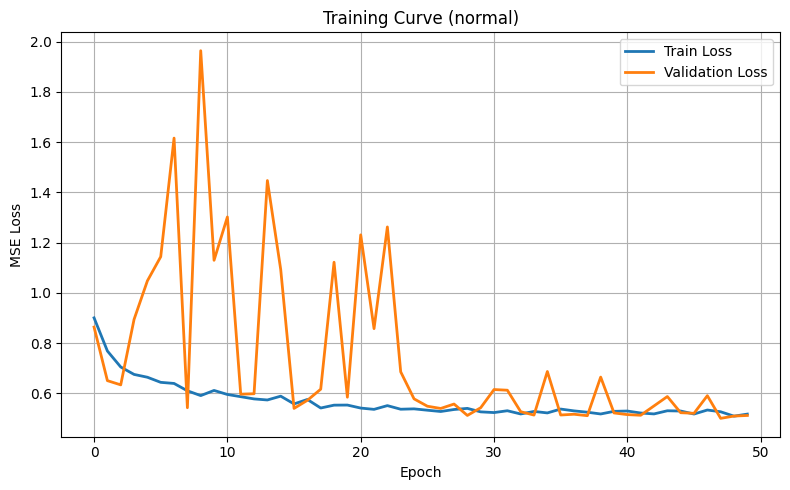

Loss curve saved as loss_curve_normal.png


In [29]:
# -----------------------------
# 5) Training loop (Stabilized)
# -----------------------------
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train()
    running_train_loss = 0.0
    
    for imgs, phys, targets in train_loader:
        imgs = imgs.to(device)
        phys = phys.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        # Check if model needs physics features
        if "physics" in MODEL_TYPE:
            outputs = model(imgs, phys)
        else:
            outputs = model(imgs)

        loss = criterion(outputs, targets)
        loss.backward()
        
        # Gradient Clipping (Critical for scratch training stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        running_train_loss += loss.item() * imgs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for imgs, phys, targets in val_loader:
            imgs = imgs.to(device)
            phys = phys.to(device)
            targets = targets.to(device)
            
            if "physics" in MODEL_TYPE:
                outputs = model(imgs, phys)
            else:
                outputs = model(imgs)

            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * imgs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # --- NEW: Step the Scheduler ---
    scheduler.step(epoch_val_loss)
    
    # Print current LR to monitor decay
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:03d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f} | LR: {current_lr:.1e}")

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        
        torch.save({
            "model_state_dict": model.state_dict(),
            "target_mean": t_mean,
            "target_std": t_std,
            "model_type": MODEL_TYPE 
        }, BEST_PATH)
        print(" -> Saved new best model.")

# -----------------------------
# 6) Plot losses
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Training Curve ({MODEL_TYPE})")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save and show
plt.savefig(f"loss_curve_{MODEL_TYPE}.png", dpi=300)
plt.show()

print(f"Loss curve saved as loss_curve_{MODEL_TYPE}.png")

In [30]:
# -----------------------------
# 7) Loading and Prediction Logic
# -----------------------------

def load_model(path, model_type="resnet"):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    
    # Initialize the correct architecture
    if model_type == "resnet":
        model = ResNet18Regressor(pretrained=False).to(device)
    elif model_type == "normal":
        model = NormalCNN().to(device)
    elif model_type == "physics":
        model = PhysicsAugmentedResNet(pretrained=False).to(device)
    elif model_type == "physics_normal":
        # --- NEW ENTRY ---
        model = PhysicsNormalCNN().to(device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
        
    model.load_state_dict(checkpoint["model_state_dict"])
    
    mean = checkpoint["target_mean"][0]
    std  = checkpoint["target_std"][0]
    
    return model, mean, std

# Transform for prediction (must match training transform's final state)
predict_tf = T.Compose([
    # T.Resize((224, 224)), # Keep commented out if you trained on 512x512
    T.ToTensor(),
])

def predict(img_path, model, mean, std, model_type="resnet"):
    model.eval()
    
    # 1. Load & Preprocess Image
    img = Image.open(img_path).convert("L")
    img_t = predict_tf(img)  # Shape: [1, H, W]

    # 2. Check if this model needs physics features
    # (Matches "physics" OR "physics_normal")
    use_physics = "physics" in model_type

    phys_t = None
    if use_physics:
        # Calculate metrics (returns shape [2])
        phys_val = calculate_physics_metrics(img_t)
        # Add batch dimension -> [1, 2]
        phys_t = phys_val.unsqueeze(0).to(device)

    # 3. Handle Channels (1 -> 3)
    # Both ResNet and our Custom CNN expect 3 channels
    if img_t.shape[0] == 1:
        img_t = img_t.repeat(3, 1, 1)      

    # 4. Add Batch Dimension -> [1, 3, H, W]
    img_t = img_t.unsqueeze(0).to(device)

    # 5. Forward Pass
    with torch.no_grad():
        if use_physics:
            # Pass both args
            out_norm = model(img_t, phys_t).cpu().numpy()[0]
        else:
            # Pass only image
            out_norm = model(img_t).cpu().numpy()[0]

    # 6. De-normalize
    out = out_norm * std + mean
    D_pred, sigma_pred = float(out[0]), float(out[1])
    
    return D_pred, sigma_pred

In [34]:
def get_ground_truth(img_path_str, csv_path):
    """Parses filename to get ID, then looks up Real D and Sigma in CSV."""
    # 1. Parse the ID from the filename
    # Assumes format: ".../mz_binary_1.png" -> "mz_binary_1.png" -> extract "1"
    filename = Path(img_path_str).name
    
    # split by '_' to get ["mz", "binary", "1.png"] then take last part and remove ".png"
    try:
        run_id_str = filename.split('_')[-1].replace(IMG_EXT, "")
        run_id = int(run_id_str)
    except ValueError:
        print(f"Error parsing ID from {filename}")
        return None, None

    # 2. Read CSV to find the values
    df = pd.read_csv(csv_path)
    
    # 3. Filter for the specific run_id
    row = df[df[IMG_INDEX_COL] == run_id]
    
    if not row.empty:
        real_D = float(row.iloc[0][COL_D])
        real_sigma = float(row.iloc[0][COL_SIGMA])
        return real_D, real_sigma
    else:
        print(f"ID {run_id} not found in CSV.")
        return None, None
# -----------------------------
# 8) Execution: Predict & Compare
# -----------------------------

# Load the model we just trained
#model, tm, ts = load_model("best_regression_model.pt", model_type=MODEL_TYPE)
model, tm, ts = load_model("best_regression_model.pt", model_type=MODEL_TYPE)

# Pick an image (Make sure this ID exists in your CSV!)
test_img_path = "../images/LTEM_images_ku_by_blocks_mz_binary/mz_binary_900.png" 

# 1. Get Prediction
# Note: We pass MODEL_TYPE here so predict() knows what to do
pred_D, pred_sigma = predict(test_img_path, model, tm, ts, model_type=MODEL_TYPE)

# 2. Get Ground Truth
real_D, real_sigma = get_ground_truth(test_img_path, CSV_PATH)

print("-" * 60)
print(f"Model Type: {MODEL_TYPE} | Image: {Path(test_img_path).name}")
print("-" * 60)
print(f"{'Parameter':<10} | {'Real Value':<12} | {'Predicted':<12} | {'Error':<12}")
print("-" * 60)

if real_D is not None:
    d_err = abs(pred_D - real_D)
    s_err = abs(pred_sigma - real_sigma)
    
    print(f"{'D':<10} | {real_D:.5f}      | {pred_D:.5f}      | {d_err:.5f}")
    print(f"{'Sigma':<10} | {real_sigma:.5f}      | {pred_sigma:.5f}      | {s_err:.5f}")
else:
    print("Could not load real values from CSV. Check filename/ID.")
print("-" * 60)

------------------------------------------------------------
Model Type: normal | Image: mz_binary_900.png
------------------------------------------------------------
Parameter  | Real Value   | Predicted    | Error       
------------------------------------------------------------
D          | 0.00141      | 0.00119      | 0.00022
Sigma      | 0.05112      | 0.07497      | 0.02385
------------------------------------------------------------


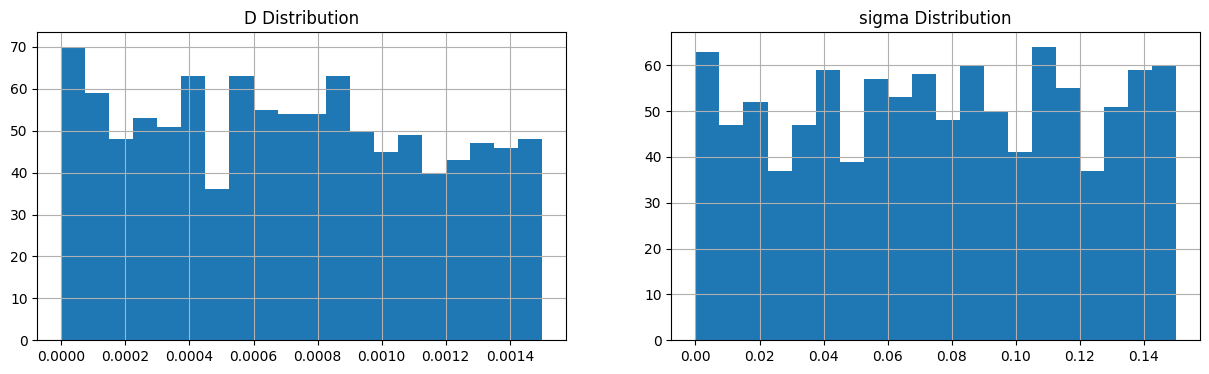

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../mumax_dataset_ku_by_block_disorder/training_index.csv")

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
df["Dind"].hist(bins=20)
plt.title("D Distribution")

plt.subplot(1,2,2)
df["sigma"].hist(bins=20)
plt.title("sigma Distribution")

plt.show()
